# Cuaderno 11 · Evidencia con datos abiertos colombianos

Los diez cuadernos anteriores usaron datos de referencia internacionales (German Credit, NSW/LaLonde). Aquí
llevamos **el recorrido completo** ---explicabilidad → causalidad → ética--- a datos **100 % colombianos**,
reproduciendo la misma estructura con un *espejo* de dos casos:

| Caso colombiano | Tipo | Análogo en el proyecto |
|---|---|---|
| **ICFES Saber 11** (datos.gov.co) | Observacional | German Credit: explicar un modelo y auditar su equidad |
| **Vouchers PACES** (Angrist et al., 2002) | **Experimental** (lotería aleatoria) | NSW/LaLonde: verdad causal de referencia |

> **Aporte y honestidad.** La maquinaria metodológica (SHAP observacional vs intervencional, CATE + SHAP,
> equidad contrafactual) no es nueva. Lo que aporta este cuaderno es **aplicado**: hasta donde sabemos, es el
> primer recorrido **reproducible** que articula XAI, inferencia causal y equidad sobre **datos abiertos
> colombianos**, cuantifica cuánta de la "importancia" que la XAI asigna al nivel socioeconómico es *proxy* y
> no causa, y ancla la auditoría de equidad en categorías colombianas (estrato, región, sector, género).

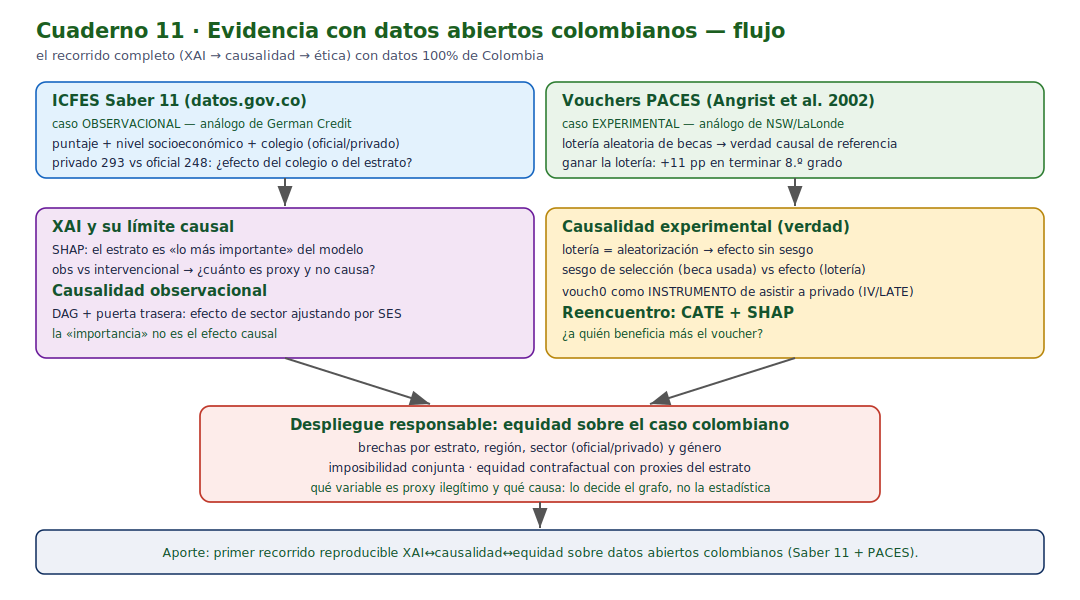

In [1]:
# Diagrama de flujo del cuaderno
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/11_flujo.svg')
if not _svg.exists():
    _svg = Path('img/11_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
for _p in ["../src", "src"]:
    if Path(_p).exists():
        sys.path.insert(0, _p)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_saber11, load_paces

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Sección 1 · Los datos

### 1.1 ICFES Saber 11 (caso observacional)

La prueba **Saber 11** es el examen estandarizado de fin de educación media en Colombia. El ICFES publica
los microdatos en el portal de datos abiertos. Tomamos una muestra reproducible de un periodo reciente
(2022, escala 0–500 posterior a la reforma de 2014) con el puntaje global y por área, las características del
colegio (naturaleza oficial/privado, jornada, bilingüe, zona) y el **nivel socioeconómico** del hogar
(estrato, educación de los padres, tenencia de internet/computador). Es el análogo del *scoring* crediticio:
entrenaremos una caja negra que prediga el puntaje y la explicaremos.

In [3]:
saber = load_saber11(periodo="20224", n=60000)
print(f"Saber 11 (2022): {saber.shape[0]:,} estudiantes  |  {saber.shape[1]} variables")
print(f"Puntaje global: media={saber.punt_global.mean():.1f}  sd={saber.punt_global.std():.1f}  "
      f"(escala 0-500)")
# Brecha observacional por naturaleza del colegio
g = saber.groupby("cole_naturaleza").punt_global.agg(["mean", "count"]).round(1)
print("\nPuntaje global por naturaleza del colegio:")
print(g)
brecha = g.loc["NO OFICIAL", "mean"] - g.loc["OFICIAL", "mean"]
print(f"\nBrecha bruta privado - oficial = {brecha:+.1f} puntos")

Saber 11 (2022): 60,000 estudiantes  |  26 variables
Puntaje global: media=259.7  sd=53.6  (escala 0-500)

Puntaje global por naturaleza del colegio:
                  mean  count
cole_naturaleza              
NO OFICIAL       293.0  15224
OFICIAL          248.4  44776

Brecha bruta privado - oficial = +44.6 puntos


Composición socioeconómica por naturaleza (canal de confusión):
                 % estrato 4-6  % con internet
cole_naturaleza                               
NO OFICIAL                23.8            91.2
OFICIAL                    4.3            68.3


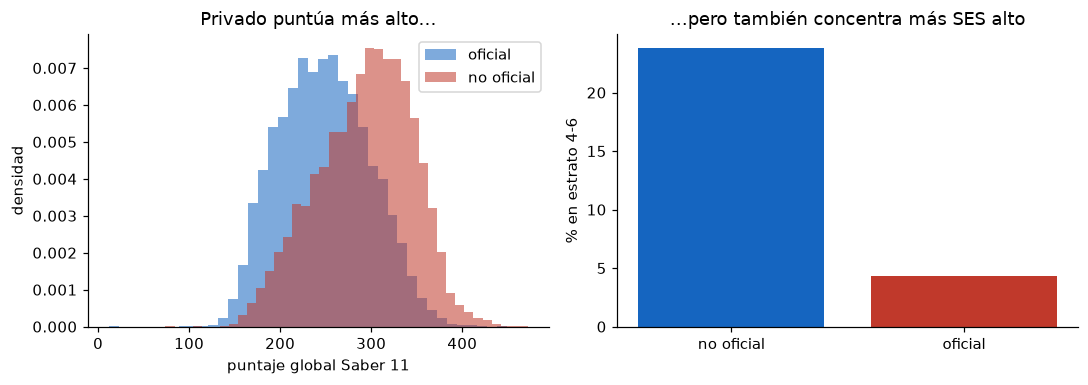

In [4]:
# ¿Es el colegio... o el estrato de quien asiste? Indicios de confusión
def pct_alto_estrato(d):
    return (d.fami_estratovivienda.isin(["Estrato 4", "Estrato 5", "Estrato 6"]).mean() * 100)
def pct_internet(d):
    return (d.fami_tieneinternet.astype(str).str.strip().str.lower().eq("si").mean() * 100)
tab = saber.groupby("cole_naturaleza").apply(
    lambda d: pd.Series({"% estrato 4-6": pct_alto_estrato(d), "% con internet": pct_internet(d)})).round(1)
print("Composición socioeconómica por naturaleza (canal de confusión):")
print(tab)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
for nat, col in [("OFICIAL", "#1565c0"), ("NO OFICIAL", "#c0392b")]:
    a1.hist(saber.loc[saber.cole_naturaleza == nat, "punt_global"], bins=40, alpha=0.55,
            density=True, label=nat.lower(), color=col)
a1.set_xlabel("puntaje global Saber 11"); a1.set_ylabel("densidad")
a1.set_title("Privado puntúa más alto..."); a1.legend()
a2.bar(tab.index.str.lower(), tab["% estrato 4-6"], color=["#1565c0", "#c0392b"])
a2.set_ylabel("% en estrato 4-6"); a2.set_title("...pero también concentra más SES alto")
plt.tight_layout(); plt.show()

### 1.2 Vouchers PACES (caso experimental)

El programa **PACES** (1991–1997) entregó becas para colegio privado a estudiantes de bajos recursos en
Colombia. Como muchas becas se asignaron por **lotería**, comparar a ganadores y perdedores estima el efecto
**sin sesgo** ---es un experimento aleatorizado natural \[Angrist, Bettinger, Bloom, King y Kremer, 2002\]---.
Usamos la muestra de Bogotá 1995. La variable `vouch0` indica haber ganado la lotería; los resultados
incluyen terminar 8.º grado (`finish8`), años de escolaridad (`scyfnsh`) y repetición (`rept`).

PACES (Bogotá 1995): 1,176 estudiantes  |  ganadores de lotería: 593

Efecto de GANAR la lotería (aleatorizado, sin sesgo):
          resultado  perdedores  ganadores  efecto (ATE)
  terminó 8.º grado       0.625      0.736         0.111
años de escolaridad       7.472      7.659         0.188
  repitió algún año       0.218      0.164        -0.054
       usó una beca       0.055      0.562         0.507


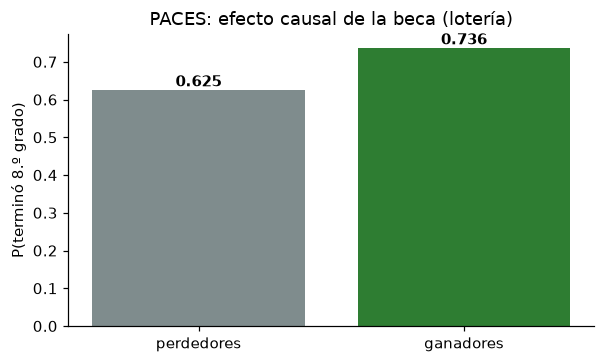

In [5]:
paces = load_paces()
bog = paces[paces["bog95smp"] == 1].copy()
print(f"PACES (Bogotá 1995): {len(bog):,} estudiantes  |  ganadores de lotería: {int(bog.vouch0.sum()):,}")
print("\nEfecto de GANAR la lotería (aleatorizado, sin sesgo):")
filas = []
for y, etq in [("finish8", "terminó 8.º grado"), ("scyfnsh", "años de escolaridad"),
               ("rept", "repitió algún año"), ("usngsch", "usó una beca")]:
    t = bog.loc[bog.vouch0 == 1, y].mean(); c = bog.loc[bog.vouch0 == 0, y].mean()
    filas.append((etq, c, t, t - c))
res = pd.DataFrame(filas, columns=["resultado", "perdedores", "ganadores", "efecto (ATE)"]).round(3)
print(res.to_string(index=False))

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.bar(["perdedores", "ganadores"], [bog.loc[bog.vouch0 == 0, "finish8"].mean(),
        bog.loc[bog.vouch0 == 1, "finish8"].mean()], color=["#7f8c8d", "#2e7d32"])
ax.set_ylabel("P(terminó 8.º grado)"); ax.set_title("PACES: efecto causal de la beca (lotería)")
for i, v in enumerate([bog.loc[bog.vouch0 == 0, "finish8"].mean(), bog.loc[bog.vouch0 == 1, "finish8"].mean()]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

> **Observación 1.1 (las dos tensiones del cuaderno).** En Saber 11, los colegios privados puntúan unos
> **45 puntos** por encima de los oficiales; pero también concentran a estudiantes de estrato alto, con más
> acceso a internet y padres más educados. ¿Cuánto de esa brecha es el **colegio** y cuánto el **nivel
> socioeconómico** de quien asiste? Es una pregunta **causal** que la predicción ---y su explicación con
> SHAP--- no responde: ese es el hilo de las Secciones 2–4. En PACES, en cambio, la **lotería** entrega la
> respuesta limpia: ganar la beca aumenta en **+11 puntos porcentuales** la probabilidad de terminar 8.º
> grado. Tener una verdad experimental colombiana nos permite, como con NSW, mostrar cuándo los métodos
> observacionales aciertan y cuándo engañan (Sección 5).

## Sección 2 · Explicar el modelo de Saber 11 y su límite causal

Entrenamos una **caja negra** que predice el puntaje global a partir del nivel socioeconómico, las
características del colegio, la región y el género; luego la explicamos con SHAP. La pregunta que guía la
sección es la misma del cuaderno 04, ahora sobre datos colombianos: *la variable "más importante" del
modelo, ¿es una causa o un proxy?*

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import shap

ses   = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre", "fami_tieneinternet",
         "fami_tienecomputador", "fami_tieneautomovil", "fami_tienelavadora", "fami_cuartoshogar",
         "fami_personashogar"]
coleg = ["cole_naturaleza", "cole_bilingue", "cole_jornada", "cole_calendario", "cole_caracter",
         "cole_area_ubicacion"]
otros = ["estu_genero", "cole_depto_ubicacion"]
cats  = ses + coleg + otros

Xs = saber[cats].astype(str)
ys = saber["punt_global"].values
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(Xs, ys, test_size=0.3, random_state=RANDOM_STATE)
pre_s = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                                 min_frequency=30), cats)], remainder="drop")
model_saber = Pipeline([("pre", pre_s),
                        ("clf", XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                                             subsample=0.9, random_state=RANDOM_STATE))]).fit(Xtr_s, ytr_s)
print(f"Modelo de puntaje (XGBoost):  R² (prueba) = {r2_score(yte_s, model_saber.predict(Xte_s)):.3f}")

Modelo de puntaje (XGBoost):  R² (prueba) = 0.380


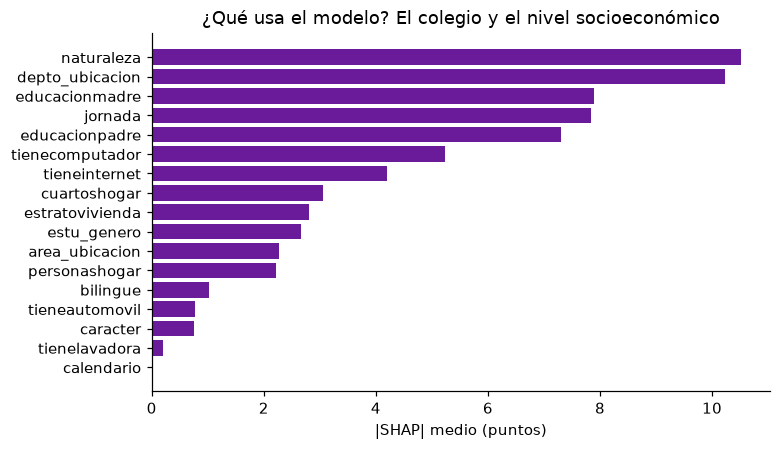

Top-5: ['cole_naturaleza', 'cole_depto_ubicacion', 'fami_educacionmadre', 'cole_jornada', 'fami_educacionpadre']


In [7]:
# Importancia SHAP, agregada por variable original (sumando sus categorías one-hot)
pre_f = model_saber.named_steps["pre"]; clf_s = model_saber.named_steps["clf"]
nombres = list(pre_f.get_feature_names_out())
Xt_te = np.asarray(pre_f.transform(Xte_s))

def agrega_por_variable(phi_vec):
    out = {}
    for nm, v in zip(nombres, phi_vec):
        b = nm.split("__", 1)[1]
        orig = next((c for c in cats if b.startswith(c)), b)
        out[orig] = out.get(orig, 0.0) + v
    return pd.Series(out)

phi_obs = np.abs(shap.TreeExplainer(clf_s, feature_perturbation="tree_path_dependent")
                 .shap_values(Xt_te[:800])).mean(0)
imp = agrega_por_variable(phi_obs).sort_values()
plt.figure(figsize=(7.2, 4.2))
plt.barh(range(len(imp)), imp.values, color="#6a1b9a")
plt.yticks(range(len(imp)), [c.replace("fami_", "").replace("cole_", "") for c in imp.index])
plt.xlabel("|SHAP| medio (puntos)"); plt.title("¿Qué usa el modelo? El colegio y el nivel socioeconómico")
plt.tight_layout(); plt.show()
print("Top-5:", list(imp.sort_values(ascending=False).head(5).index))

In [8]:
# Explicación LOCAL de un estudiante: qué empuja su puntaje predicho
expl = shap.TreeExplainer(clf_s, feature_perturbation="tree_path_dependent")
i = 7
sv_i = expl.shap_values(Xt_te[i:i+1])[0]
contrib = agrega_por_variable(sv_i).sort_values(key=np.abs, ascending=False).head(6)
pred_i = model_saber.predict(Xte_s.iloc[i:i+1])[0]
print(f"Estudiante de ejemplo: puntaje predicho = {pred_i:.0f}  (media del modelo ≈ {ys.mean():.0f})")
print("Sus características:")
for c in contrib.index:
    print(f"  {c:24s} = {Xte_s.iloc[i][c]!s:18s} -> SHAP {contrib[c]:+.1f}")

Estudiante de ejemplo: puntaje predicho = 246  (media del modelo ≈ 260)
Sus características:
  fami_tieneinternet       = No                 -> SHAP -7.2
  cole_naturaleza          = OFICIAL            -> SHAP -6.9
  fami_tienecomputador     = No                 -> SHAP -6.2
  fami_educacionpadre      = Educación profesional completa -> SHAP +4.9
  estu_genero              = F                  -> SHAP -2.5
  cole_area_ubicacion      = URBANO             -> SHAP +2.3


In [9]:
# Observacional vs intervencional: ¿cuánta importancia es 'prestada' por correlación?
phi_int = np.abs(shap.TreeExplainer(clf_s, data=np.asarray(pre_f.transform(Xtr_s.iloc[:300])),
                                    feature_perturbation="interventional").shap_values(Xt_te[:300])).mean(0)
obs = agrega_por_variable(np.abs(shap.TreeExplainer(clf_s, feature_perturbation="tree_path_dependent")
                                 .shap_values(Xt_te[:300])).mean(0))
inte = agrega_por_variable(phi_int)
comp = pd.DataFrame({"observacional": obs, "intervencional": inte})
comp = comp.loc[comp["observacional"].sort_values(ascending=False).head(6).index]
comp["cociente"] = (comp["intervencional"] / comp["observacional"]).round(2)
print("Atribución observacional vs intervencional (top-6):")
print(comp.round(2))

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


Atribución observacional vs intervencional (top-6):
                      observacional  intervencional  cociente
cole_naturaleza               10.91            8.23      0.75
cole_depto_ubicacion          10.17            9.87      0.97
cole_jornada                   8.02            7.22      0.90
fami_educacionmadre            7.79            8.31      1.07
fami_educacionpadre            7.28            6.77      0.93
fami_tienecomputador           5.18            4.93      0.95


> **Observación 2.1.** SHAP muestra que el modelo se apoya, sobre todo, en la **naturaleza del colegio**
> (oficial/privado), el **departamento** y la **educación de la madre**. Pero "importante para el modelo"
> significa *correlación aprendida*, no causa: que el colegio privado encabece la lista **no** prueba que el
> colegio eleve el puntaje ---podría ser un **proxy** del estrato de quien asiste (Sección 1)---. La
> comparación observacional vs intervencional confirma que parte de la atribución se reparte entre variables
> correlacionadas con el nivel socioeconómico. Separar el efecto del colegio del efecto del estrato es una
> pregunta **causal**, no de explicabilidad: la abordamos en las Secciones 3 y 4.

## Sección 3 · ¿El colegio o el estrato? Ajuste por puerta trasera

La asociación bruta entre asistir a un colegio privado y el puntaje es de **+44.6 puntos** (Sección 1). Pero
esa diferencia está **confundida**: el nivel socioeconómico ---estrato, educación de los padres, acceso a
recursos--- determina a la vez **quién asiste a un privado** y **el puntaje**. El DAG es el del cuaderno 06:

$$ \text{SES} \longrightarrow \text{sector (privado)}, \qquad \text{SES} \longrightarrow \text{puntaje},
   \qquad \text{sector} \longrightarrow \text{puntaje}\,? $$

El SES es **causa común** (confusor) y abre un camino de puerta trasera. Bajo ignorabilidad condicional y
positividad, el criterio de puerta trasera (cuaderno 06) identifica el efecto **ajustando por el SES** (y la
región). Lo estimamos por regresión-ajuste y por ponderación inversa (IPW).

Efecto del sector privado sobre el puntaje Saber 11:
  asociación bruta (naive)        = +44.6 puntos
  ajustado por SES (regresión)    = +23.3 puntos
  ajustado por SES (IPW)          = +25.2 puntos
  => confusión por SES: 48% (regresión), 44% (IPW)


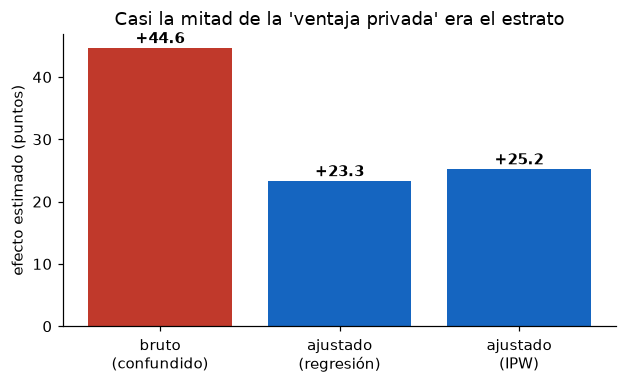

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier

T = (saber["cole_naturaleza"] == "NO OFICIAL").astype(int).values     # 1 = privado
Y = saber["punt_global"].values
Z = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre", "fami_tieneinternet",
     "fami_tienecomputador", "fami_tieneautomovil", "fami_tienelavadora", "fami_cuartoshogar",
     "fami_personashogar", "estu_genero", "cole_depto_ubicacion", "cole_area_ubicacion"]
encZ = ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                              min_frequency=30), Z)])
Zx = encZ.fit_transform(saber[Z].astype(str))

naive = Y[T == 1].mean() - Y[T == 0].mean()
adj_ols = LinearRegression().fit(np.column_stack([T, Zx]), Y).coef_[0]     # regresión-ajuste
e = GradientBoostingClassifier(max_depth=3, n_estimators=150, random_state=RANDOM_STATE).fit(Zx, T).predict_proba(Zx)[:, 1]
e = np.clip(e, 0.02, 0.98); w = T / e + (1 - T) / (1 - e)
adj_ipw = (np.sum(w * T * Y) / np.sum(w * T)) - (np.sum(w * (1 - T) * Y) / np.sum(w * (1 - T)))

print(f"Efecto del sector privado sobre el puntaje Saber 11:")
print(f"  asociación bruta (naive)        = {naive:+.1f} puntos")
print(f"  ajustado por SES (regresión)    = {adj_ols:+.1f} puntos")
print(f"  ajustado por SES (IPW)          = {adj_ipw:+.1f} puntos")
print(f"  => confusión por SES: {100*(1-adj_ols/naive):.0f}% (regresión), {100*(1-adj_ipw/naive):.0f}% (IPW)")

fig, ax = plt.subplots(figsize=(5.8, 3.6))
vals = [naive, adj_ols, adj_ipw]
ax.bar(["bruto\n(confundido)", "ajustado\n(regresión)", "ajustado\n(IPW)"], vals,
       color=["#c0392b", "#1565c0", "#1565c0"])
for i, v in enumerate(vals):
    ax.text(i, v + 0.8, f"{v:+.1f}", ha="center", fontweight="bold")
ax.set_ylabel("efecto estimado (puntos)"); ax.set_title("Casi la mitad de la 'ventaja privada' era el estrato")
plt.tight_layout(); plt.show()

> **Observación 3.1.** Al bloquear el camino de puerta trasera por el SES, la "ventaja" del colegio
> privado se reduce de **+44.6** a **≈ +24** puntos: **cerca de la mitad de la brecha bruta era confusión
> socioeconómica**, no el colegio. Es la misma lección del cuaderno 04, ahora sobre educación colombiana: la
> "importancia" que la XAI asignaba al sector mezclaba el efecto del colegio con el del estrato de quien
> asiste. **Pero atención:** esto sigue siendo **observacional**. La ignorabilidad ---que el SES medido capte
> *toda* la confusión--- **no es verificable**; pueden quedar confusores no observados (motivación, aptitud
> previa, apoyo familiar), de modo que **+24 es un techo, no un efecto limpio**. Para tener una respuesta sin
> ese supuesto hace falta un **experimento**: justo lo que ofrece PACES (Sección 4).

## Sección 4 · La verdad experimental: la lotería PACES

La Sección 3 dejó una respuesta a medias: ajustar por el SES observable es lo mejor que puede hacer un
diseño observacional, pero la ignorabilidad no es verificable. PACES rompe el nudo con **aleatorización**:
como las becas se asignaron por **lotería**, ganar es independiente de todo ---observado o no---. Es el
análogo colombiano del experimento NSW (cuaderno 05), y permite tres lecturas:

- el **efecto de ganar la lotería** (intención de tratar, ITT): la pregunta de política;
- el **sesgo de selección** de comparar a quienes *usaron* una beca con quienes no;
- la lotería como **instrumento** del uso de la beca (IV/2SLS), que recupera su efecto local (LATE).

In [11]:
# Chequeo de aleatorización: ganadores y perdedores deben estar balanceados
d = bog.dropna(subset=["finish8", "vouch0", "usngsch"]).copy()
T = d["vouch0"].values; U = d["usngsch"].values; Yf = d["finish8"].values
bal = []
for v, etq in [("mom_sch", "educación madre"), ("dad_sch", "educación padre"),
               ("age", "edad"), ("strata2", "estrato 2")]:
    dd = bog.dropna(subset=[v, "vouch0"])
    bal.append((etq, dd.loc[dd.vouch0 == 1, v].mean(), dd.loc[dd.vouch0 == 0, v].mean()))
balance = pd.DataFrame(bal, columns=["covariable", "ganadores", "perdedores"]).round(2)
print("Balance de covariables por resultado de la lotería (debe ser ≈ igual):")
print(balance.to_string(index=False))

Balance de covariables por resultado de la lotería (debe ser ≈ igual):
     covariable  ganadores  perdedores
educación madre       5.85        5.89
educación padre       5.53        5.89
           edad      14.97       15.04
      estrato 2       0.56        0.56


ITT  (ganar la lotería)            = +0.111
primera etapa (lotería -> beca)    = +0.507   (instrumento fuerte)
IV / LATE (usar la beca, limpio)   = +0.219
naive (beca usada vs no, sesgado)  = +0.403
=> el ingenuo SOBREESTIMA el efecto de la beca en 84% (selección positiva)


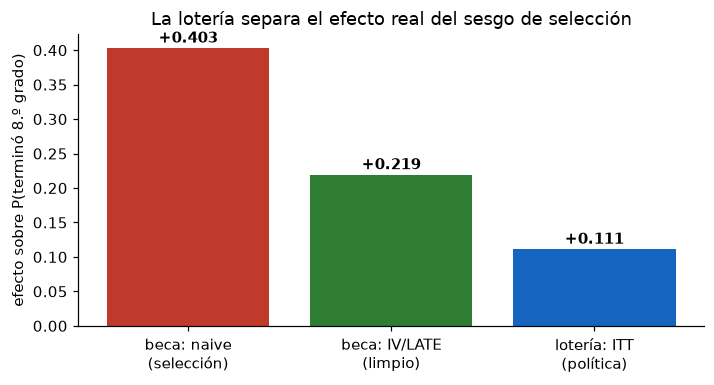

In [12]:
# Tres estimaciones sobre 'terminar 8.º grado'
itt   = Yf[T == 1].mean() - Yf[T == 0].mean()          # efecto de GANAR (ITT)
first = U[T == 1].mean()  - U[T == 0].mean()            # primera etapa: loteria -> beca
iv    = itt / first                                     # Wald: efecto de USAR la beca (LATE)
naive = Yf[U == 1].mean() - Yf[U == 0].mean()           # comparacion ingenua por uso de beca

print(f"ITT  (ganar la lotería)            = {itt:+.3f}")
print(f"primera etapa (lotería -> beca)    = {first:+.3f}   (instrumento fuerte)")
print(f"IV / LATE (usar la beca, limpio)   = {iv:+.3f}")
print(f"naive (beca usada vs no, sesgado)  = {naive:+.3f}")
print(f"=> el ingenuo SOBREESTIMA el efecto de la beca en {100*(naive/iv-1):.0f}% (selección positiva)")

fig, ax = plt.subplots(figsize=(6.6, 3.6))
vals = [naive, iv, itt]
ax.bar(["beca: naive\n(selección)", "beca: IV/LATE\n(limpio)", "lotería: ITT\n(política)"],
       vals, color=["#c0392b", "#2e7d32", "#1565c0"])
for i, v in enumerate(vals):
    ax.text(i, v + 0.008, f"{v:+.3f}", ha="center", fontweight="bold")
ax.set_ylabel("efecto sobre P(terminó 8.º grado)")
ax.set_title("La lotería separa el efecto real del sesgo de selección")
plt.tight_layout(); plt.show()

> **Observación 4.1.** La lotería deja a ganadores y perdedores **balanceados** en SES y edad: la
> comparación es causal por diseño, sin supuestos no verificables. Y revela el engaño observacional: la
> comparación ingenua por *uso de beca* (**+0.40**) casi **duplica** el efecto limpio estimado por
> variables instrumentales (**+0.22**), porque quienes usan la beca están **positivamente seleccionados**
> (más motivación o apoyo). Es la lección de LaLonde (cuaderno 05) sobre datos colombianos: cuando hay un
> experimento, expone el sesgo de los métodos observacionales; y la misma lotería sirve de **instrumento**
> válido (cuaderno 08) para recuperar el efecto de usar la beca. La asignación aleatoria es el patrón de oro
> que el ajuste de la Sección 3 solo puede *aproximar*.

## Sección 5 · El reencuentro: ¿a quién beneficia más el voucher?

Aquí se reúnen las dos disciplinas, como en el cuaderno 09: estimamos el efecto **heterogéneo** del voucher
(CATE) sobre los años de escolaridad y lo **explicamos con SHAP**. No se explica una predicción, sino un
**efecto causal estimado**. Como PACES es aleatorizado, el CATE se identifica sin supuestos no verificables
(aunque la muestra es pequeña, así que es ruidoso).

In [13]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import xgboost as xgb

Xcols = ["sex", "age", "mom_sch", "dad_sch", "strata2", "strata3", "dbogota"]
dd = bog.dropna(subset=["scyfnsh", "vouch0"] + Xcols).copy()
for c in Xcols:
    dd[c] = pd.to_numeric(dd[c], errors="coerce")
dd = dd.dropna(subset=Xcols)
Yv = dd["scyfnsh"].values; Tv = dd["vouch0"].astype(int).values; Xv = dd[Xcols].values

cf = CausalForestDML(model_y=RandomForestRegressor(n_estimators=300, min_samples_leaf=15, random_state=RANDOM_STATE),
                     model_t=RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
                     discrete_treatment=True, random_state=RANDOM_STATE).fit(Yv, Tv, X=Xv)
tau = cf.effect(Xv)
print(f"n={len(dd)}  |  ATE (años de escolaridad) = {cf.ate(Xv):+.3f}")
print(f"CATE: rango [{tau.min():+.2f}, {tau.max():+.2f}], sd={tau.std():.2f}  -> hay heterogeneidad")

n=819  |  ATE (años de escolaridad) = +0.193
CATE: rango [-0.29, +0.74], sd=0.20  -> hay heterogeneidad


Validación por focalización (ITT realizado, válido por aleatorización):
  mitad de MAYOR CATE predicho: +0.440 años
  mitad de MENOR CATE predicho: -0.129 años


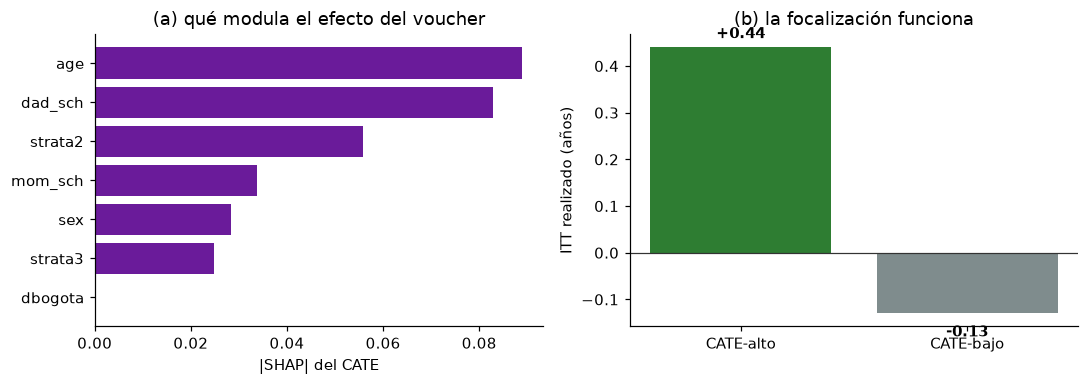

In [14]:
# SHAP del CATE (qué genera la heterogeneidad) + validación por focalización
phi = np.abs(shap.TreeExplainer(xgb.XGBRegressor(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)
             .fit(Xv, tau)).shap_values(Xv)).mean(0)
imp = pd.Series(phi, index=Xcols).sort_values()

hi = tau >= np.median(tau)
ate_hi = Yv[hi & (Tv == 1)].mean() - Yv[hi & (Tv == 0)].mean()
ate_lo = Yv[~hi & (Tv == 1)].mean() - Yv[~hi & (Tv == 0)].mean()
print(f"Validación por focalización (ITT realizado, válido por aleatorización):")
print(f"  mitad de MAYOR CATE predicho: {ate_hi:+.3f} años")
print(f"  mitad de MENOR CATE predicho: {ate_lo:+.3f} años")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.barh(range(len(imp)), imp.values, color="#6a1b9a")
a1.set_yticks(range(len(imp))); a1.set_yticklabels(imp.index)
a1.set_xlabel("|SHAP| del CATE"); a1.set_title("(a) qué modula el efecto del voucher")
a2.bar(["CATE-alto", "CATE-bajo"], [ate_hi, ate_lo], color=["#2e7d32", "#7f8c8d"])
a2.axhline(0, color="#333", lw=0.8); a2.set_ylabel("ITT realizado (años)")
a2.set_title("(b) la focalización funciona")
for i, v in enumerate([ate_hi, ate_lo]):
    a2.text(i, v + (0.02 if v >= 0 else -0.05), f"{v:+.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

> **Observación 5.1.** El SHAP del CATE indica que la **edad** y la **educación del padre** son las que más
> modulan el beneficio del voucher; el efecto no es uniforme. La validación lo confirma: la mitad de mayor
> CATE predicho realiza un efecto de **+0.44 años** de escolaridad, frente a **−0.13** en la mitad de menor
> CATE ---focalizar la beca en quienes más se benefician multiplica su impacto---. Es el reencuentro del
> cuaderno 09 sobre datos colombianos: explicar (con SHAP) un **efecto causal** estimado, no una predicción.
> *Salvedad honesta:* la muestra de PACES es pequeña (≈ 800), así que el CATE es ruidoso y estas señales son
> sugerentes; el valor aquí es metodológico ---el flujo corre de extremo a extremo sobre datos reales.

## Sección 6 · Despliegue responsable: equidad en una selección por mérito

Imaginemos que el puntaje predicho se usa para **seleccionar al 30 % "de mayor mérito"** ---una beca o un
cupo---. Auditamos esa decisión por **estrato** y **género**, como en el cuaderno 10, sobre el caso
colombiano. La pregunta de fondo: ¿una selección "por mérito" es justa, o reproduce la desigualdad de
origen?

In [15]:
from xgboost import XGBClassifier

thr = np.quantile(saber.punt_global, 0.70)
saber["alto"] = (saber.punt_global >= thr).astype(int)          # 'alto desempeño' (top 30%)
_estr = saber.fami_estratovivienda.str.extract(r"(\d)").astype(float)[0]
saber["estrato_bajo"] = (_estr <= 2)

ses_f = ["fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre", "fami_tieneinternet",
         "fami_tienecomputador", "fami_tieneautomovil", "fami_tienelavadora", "fami_cuartoshogar",
         "fami_personashogar"]
col_f = ["cole_naturaleza", "cole_bilingue", "cole_jornada", "cole_calendario", "cole_caracter",
         "cole_area_ubicacion", "cole_depto_ubicacion", "estu_genero"]
allc = ses_f + col_f
blindc = [c for c in allc if not c.startswith("fami_estrato")]      # modelo 'ciego al estrato'

def fit_clf(cols, Xtr, ytr):
    pre = ColumnTransformer([("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                                 min_frequency=30), cols)])
    return Pipeline([("p", pre), ("m", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                                     eval_metric="logloss", random_state=RANDOM_STATE))]).fit(Xtr[cols], ytr)

tr_idx, te_idx = train_test_split(saber.index, test_size=0.3, random_state=RANDOM_STATE)
Xtr_f, Xte_f = saber.loc[tr_idx], saber.loc[te_idx]
m_full = fit_clf(allc, Xtr_f, saber.loc[tr_idx, "alto"])
m_blind = fit_clf(blindc, Xtr_f, saber.loc[tr_idx, "alto"])
pf = m_full.predict_proba(Xte_f[allc])[:, 1]; pb = m_blind.predict_proba(Xte_f[blindc])[:, 1]
sel_full = (pf >= np.quantile(pf, 0.70)).astype(int)
sel_blind = (pb >= np.quantile(pb, 0.70)).astype(int)
eb = Xte_f["estrato_bajo"].values; act = Xte_f["alto"].values; fem = (Xte_f.estu_genero == "F").values

print(f"Tasa base (alto real):     estrato bajo={act[eb].mean():.2f}  alto={act[~eb].mean():.2f}")
print(f"Selección modelo COMPLETO: bajo={sel_full[eb].mean():.2f}  alto={sel_full[~eb].mean():.2f}  "
      f"(brecha {sel_full[~eb].mean()-sel_full[eb].mean():.2f})")
print(f"Selección modelo CIEGO:    bajo={sel_blind[eb].mean():.2f}  alto={sel_blind[~eb].mean():.2f}  "
      f"(brecha {sel_blind[~eb].mean()-sel_blind[eb].mean():.2f})")
print(f"Selección por género:      F={sel_full[fem].mean():.2f}  M={sel_full[~fem].mean():.2f}")

Tasa base (alto real):     estrato bajo=0.26  alto=0.37
Selección modelo COMPLETO: bajo=0.20  alto=0.45  (brecha 0.26)
Selección modelo CIEGO:    bajo=0.19  alto=0.45  (brecha 0.26)
Selección por género:      F=0.25  M=0.37


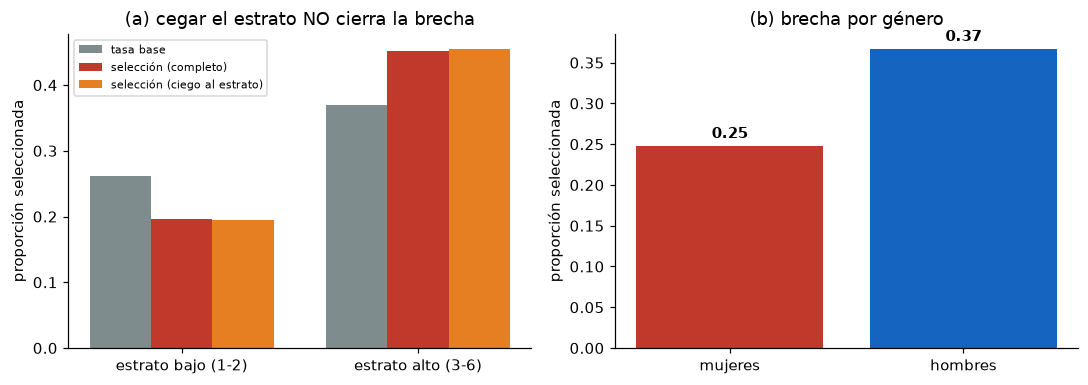

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
x = np.arange(2); w = 0.26
a1.bar(x - w, [act[eb].mean(), act[~eb].mean()], w, label="tasa base", color="#7f8c8d")
a1.bar(x,     [sel_full[eb].mean(), sel_full[~eb].mean()], w, label="selección (completo)", color="#c0392b")
a1.bar(x + w, [sel_blind[eb].mean(), sel_blind[~eb].mean()], w, label="selección (ciego al estrato)", color="#e67e22")
a1.set_xticks(x); a1.set_xticklabels(["estrato bajo (1-2)", "estrato alto (3-6)"])
a1.set_ylabel("proporción seleccionada"); a1.set_title("(a) cegar el estrato NO cierra la brecha")
a1.legend(fontsize=7.5)
a2.bar(["mujeres", "hombres"], [sel_full[fem].mean(), sel_full[~fem].mean()], color=["#c0392b", "#1565c0"])
a2.set_ylabel("proporción seleccionada"); a2.set_title("(b) brecha por género")
for i, v in enumerate([sel_full[fem].mean(), sel_full[~fem].mean()]):
    a2.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

> **Observación 6.1.** La selección "por mérito" **reproduce y amplifica** la desigualdad de origen: el
> estrato alto es seleccionado en un **45 %** frente al **20 %** del estrato bajo, cuando las tasas base
> reales son 37 % y 26 % (el modelo *amplía* la brecha). Como las tasas base difieren, el **Teorema de
> imposibilidad** (cuaderno 10) impide igualar todos los criterios a la vez. Y lo decisivo: un modelo
> **ciego al estrato** conserva **la misma brecha** (0.26), porque la educación de los padres, el internet y
> el computador son **proxies** del estrato. La "equidad por desconocimiento" es una ilusión también en la
> educación colombiana. Qué proxy es legítimo ---¿la educación de los padres mide aptitud o solo origen?---
> no lo decide la estadística, sino el **modelo causal** y el debate de política. La brecha de **género**
> (mujeres 25 % vs hombres 37 %) añade otra dimensión que auditar.

## Sección 7 · Síntesis y aporte

El recorrido completo ---XAI → causalidad → ética--- corrió de extremo a extremo sobre **datos abiertos
colombianos**, reproduciendo la estructura del proyecto con dos casos locales.

| Pregunta | Resultado (datos colombianos) |
|---|---|
| **XAI:** ¿qué usa el modelo de puntaje? | colegio (oficial/privado), departamento y educación de la madre; \(R^2=0.38\) |
| **¿proxy o causa?** (SHAP obs vs intervencional) | la importancia del sector **cae ~25 %** al intervenir |
| **Causal observacional** (puerta trasera) | la "ventaja privada" pasa de **+44.6** a **≈ +24** puntos (≈ mitad era SES) |
| **Experimental** (lotería PACES) | ITT \(+0.111\); selección ingenua \(+0.40\) vs **IV/LATE \(+0.22\)** |
| **Reencuentro** (CATE del voucher) | focalización: CATE-alto \(+0.44\) vs CATE-bajo \(-0.13\) años |
| **Equidad** | brecha de selección por estrato **0.26**; modelo ciego = **igual** (proxies); género 0.25 vs 0.37 |

### ¿Cuál es el aporte original?

La **maquinaria metodológica no es nueva** (SHAP observacional/intervencional, CATE + SHAP, equidad
contrafactual son métodos existentes). El aporte es **aplicado y, en ese plano, genuino**:

1. Hasta donde alcanza nuestra revisión, es el **primer recorrido reproducible** que articula explicabilidad,
   inferencia causal y equidad sobre **datos abiertos colombianos** (Saber 11 + PACES) en una sola línea.
2. **Cuantifica, sobre datos reales colombianos, que cerca de la mitad de la brecha público/privado en
   Saber 11 es composición socioeconómica, no el colegio** ---y que la XAI por sí sola no lo distingue---.
3. Muestra, con la **lotería PACES**, que las comparaciones observacionales de "uso de beca" casi **duplican**
   el efecto causal (IV/LATE), replicando la lección de LaLonde con un experimento **colombiano**.
4. Audita una **selección por mérito** y evidencia que **reproduce y amplifica** la desigualdad de estrato, y
   que cegar el atributo no la corrige porque sus **proxies** persisten ---un resultado de relevancia directa
   para el debate de equidad educativa en Colombia.

### Limitaciones (honestas)

- La identificación en **Saber 11 es observacional**: la ignorabilidad no es verificable, así que el efecto
  ajustado del sector (\(\approx +24\)) es un **techo**, no un efecto limpio.
- La muestra de **PACES es pequeña** (\(\approx 800\)): el CATE es ruidoso y la heterogeneidad es sugerente.
- El **DAG de proxies del estrato es ilustrativo**; decidir qué proxy es legítimo exige conocimiento de
  dominio y discusión de política.
- Se usó **una cohorte** de Saber (2022) y una submuestra fija; ampliar a varios años reforzaría los
  hallazgos.

> **Cierre.** Con datos 100 % colombianos se sostiene la misma tesis del proyecto: explicar no es entender.
> La XAI hace transparente la correlación; entender la brecha educativa y desplegar una decisión justa exige
> el lenguaje **causal** y una mirada **ética** ---juntas.

## Referencias

- Angrist, J., Bettinger, E., Bloom, E., King, E., & Kremer, M. (2002). Vouchers for private schooling in
  Colombia: Evidence from a randomized natural experiment. *American Economic Review, 92*(5), 1535–1558.
- ICFES. (2024). *Resultados únicos Saber 11* \[conjunto de datos abiertos\]. Portal de Datos Abiertos de
  Colombia, datos.gov.co.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*.
- Janzing, D., Minorics, L., & Blöbaum, P. (2020). Feature relevance quantification in explainable AI: A
  causal problem. *AISTATS*.
- Pearl, J. (2009). *Causality: Models, reasoning, and inference* (2.ª ed.). Cambridge University Press.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies.
  *Journal of Educational Psychology, 66*(5), 688–701.
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects using random
  forests. *JASA, 113*(523), 1228–1242.
- Chouldechova, A. (2017). Fair prediction with disparate impact. *Big Data, 5*(2), 153–163.
- Kusner, M. J., Loftus, J., Russell, C., & Silva, R. (2017). Counterfactual fairness. *NeurIPS 30*.